In [1]:
import pandas as pd

In [2]:
import chardet

with open("cleaned_earthquakes1.csv", 'rb') as f:
    result = chardet.detect(f.read(100000))
print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [3]:
eq_df = pd.read_csv('cleaned_earthquakes1.csv', encoding='utf-8')

In [4]:
eq_df

,time,latitude,longitude,depth,mag,magType,gap,rms,net,id,updated,place,type,depthError,status,locationSource,magSource
0,2010-01-29T23:22:52.490Z,51.841000,177.738000,48.200,3.60,ml,201.5,0.76,us,usp000h6s8,2018-07-06T19:53:37.173Z,"Rat Islands, Aleutian Islands, Alaska",earthquake,4.665,reviewed,aeic,aeic
1,2010-01-29T22:25:34.910Z,51.672000,177.745000,73.000,5.00,mb,115.0,0.86,us,usp000h6s7,2018-07-06T19:53:29.300Z,"Rat Islands, Aleutian Islands, Alaska",earthquake,2.800,reviewed,us,us
2,2010-01-29T20:47:53.200Z,1.585000,-90.602000,10.000,5.60,mwc,80.1,1.07,us,usp000h6s6,2022-05-02T21:35:53.294Z,"259 km N of Puerto Ayora, Ecuador",earthquake,4.665,reviewed,us,gcmt
3,2010-01-29T20:38:08.450Z,1.514000,-90.714000,10.000,5.20,mwc,159.9,1.15,us,usp000h6s5,2016-11-10T02:23:29.680Z,"253 km N of Puerto Ayora, Ecuador",earthquake,4.665,reviewed,us,gcmt
4,2010-01-29T17:52:23.040Z,4.726000,-75.971000,131.500,4.90,mwc,52.5,0.95,us,usp000h6s2,2022-07-16T01:38:25.589Z,"6 km WSW of Cartago, Colombia",earthquake,4.665,reviewed,us,gcmt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243107,2023-04-01T02:18:48.550Z,2.834600,127.183300,24.303,4.30,mb,131.0,0.95,us,us6000k2cl,2023-04-07T00:10:37.040Z,Molucca Sea,earthquake,6.441,reviewed,us,us
243108,2023-04-01T02:06:43.037Z,56.766500,-154.630500,9.900,3.00,ml,111.0,0.65,ak,ak02346j4tsk,2023-04-07T00:01:04.319Z,"34 km SW of Akhiok, Alaska",earthquake,0.500,reviewed,ak,ak
243109,2023-04-01T01:16:07.810Z,33.381667,-116.909667,12.960,4.15,mw,18.0,0.21,ci,ci39508378,2023-04-13T23:16:58.312Z,"5km NW of Palomar Observatory, CA",earthquake,0.370,reviewed,ci,ci
243110,2023-04-01T00:47:43.686Z,-20.926400,-70.471500,31.966,4.20,mb,125.0,0.85,us,us6000k19h,2023-04-08T02:12:03.321Z,"Near the coast of Tarapaca, Chile",earthquake,6.671,reviewed,us,us



Top correlations with magnitude:

                 mag
mag         1.000000
longitude   0.400028
rms         0.371985
depth       0.085302
depthError -0.068700
latitude   -0.439254
gap        -0.485698


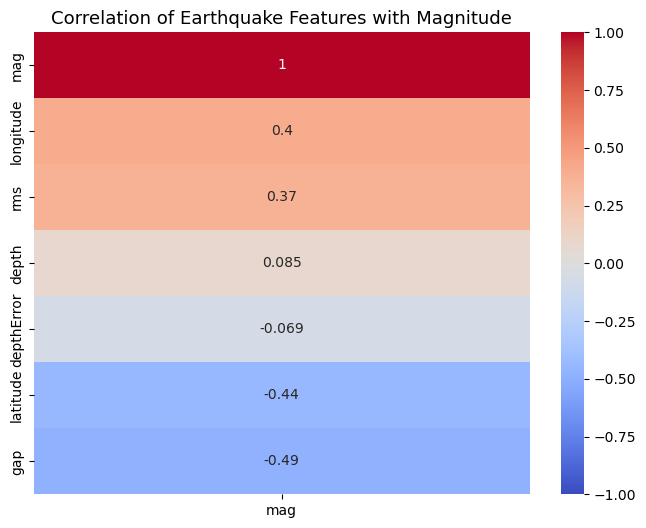

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Select numeric columns
numeric_eq = eq_df.select_dtypes(include=[np.number])

# Compute correlations
corr_eq = numeric_eq.corr()

# Focus on correlation with magnitude
target_corr_eq = corr_eq[['mag']].sort_values(by='mag', ascending=False)

# Display top correlations
print("\nTop correlations with magnitude:\n")
print(target_corr_eq.head(17))

# --- Plot heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(target_corr_eq, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Earthquake Features with Magnitude', fontsize=13)
plt.show()


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy dataset
eq_model_df = eq_df.copy()

# Encode categorical columns (like magType, type, net, locationSource)
cat_cols = eq_model_df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    eq_model_df[col] = le.fit_transform(eq_model_df[col].astype(str))

# Features (exclude mag itself)
X_eq = eq_model_df.drop(columns=['mag'])
y_eq = eq_model_df['mag']

# Split dataset
X_train_eq, X_test_eq, y_train_eq, y_test_eq = train_test_split(X_eq, y_eq, test_size=0.2, random_state=42)

# Train Random Forest
rf_eq = RandomForestRegressor(n_estimators=200, random_state=42)
rf_eq.fit(X_train_eq, y_train_eq)

# Feature importance
importances_eq = pd.Series(rf_eq.feature_importances_, index=X_eq.columns).sort_values(ascending=False)

# Display top features
print("\nTop 15 Feature Importances for Earthquake Magnitude:\n")
print(importances_eq.head(15))

# Plot
plt.figure(figsize=(10, 6))
importances_eq.head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances for Earthquake Magnitude (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.show()


MemoryError: could not allocate 8388608 bytes